In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("FINAL_DATASET.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'FINAL_DATASET.csv'

In [3]:
results = pd.read_csv("../final_results.csv")
results

,train,test,19631,14973,10315,5657,1000
0,cgreGFP,cgreGFP,0.8783_0.0036,0.8713_0.0031,0.8633_0.0066,0.8392_0.0059,0.6264_0.0466
1,cgreGFP,cgre1338 cgre132 cgre9708 cgre4111,0.6236_0.0558,0.6223_0.1060,0.5370_0.1080,0.4920_0.1121,0.3731_0.2042
2,cgreGFP,cgreGFP cgre1338 cgre132 cgre9708 cgre4111,0.7998_0.0136,0.7422_0.0523,0.7750_0.0157,0.7345_0.0251,0.5069_0.0437
3,cgre1338 cgre132 cgre9708 cgre4111,cgreGFP,0.8248_0.0139,0.8246_0.0079,0.7985_0.0100,0.7586_0.0353,0.4787_0.0667
4,cgre1338 cgre132 cgre9708 cgre4111,cgre1338 cgre132 cgre9708 cgre4111,0.8072_0.0070,0.8039_0.0122,0.7853_0.0041,0.7709_0.0133,0.6132_0.0193
5,cgre1338 cgre132 cgre9708 cgre4111,cgreGFP cgre1338 cgre132 cgre9708 cgre4111,0.8092_0.0187,0.7995_0.0068,0.7882_0.0183,0.7435_0.0202,0.4441_0.1268


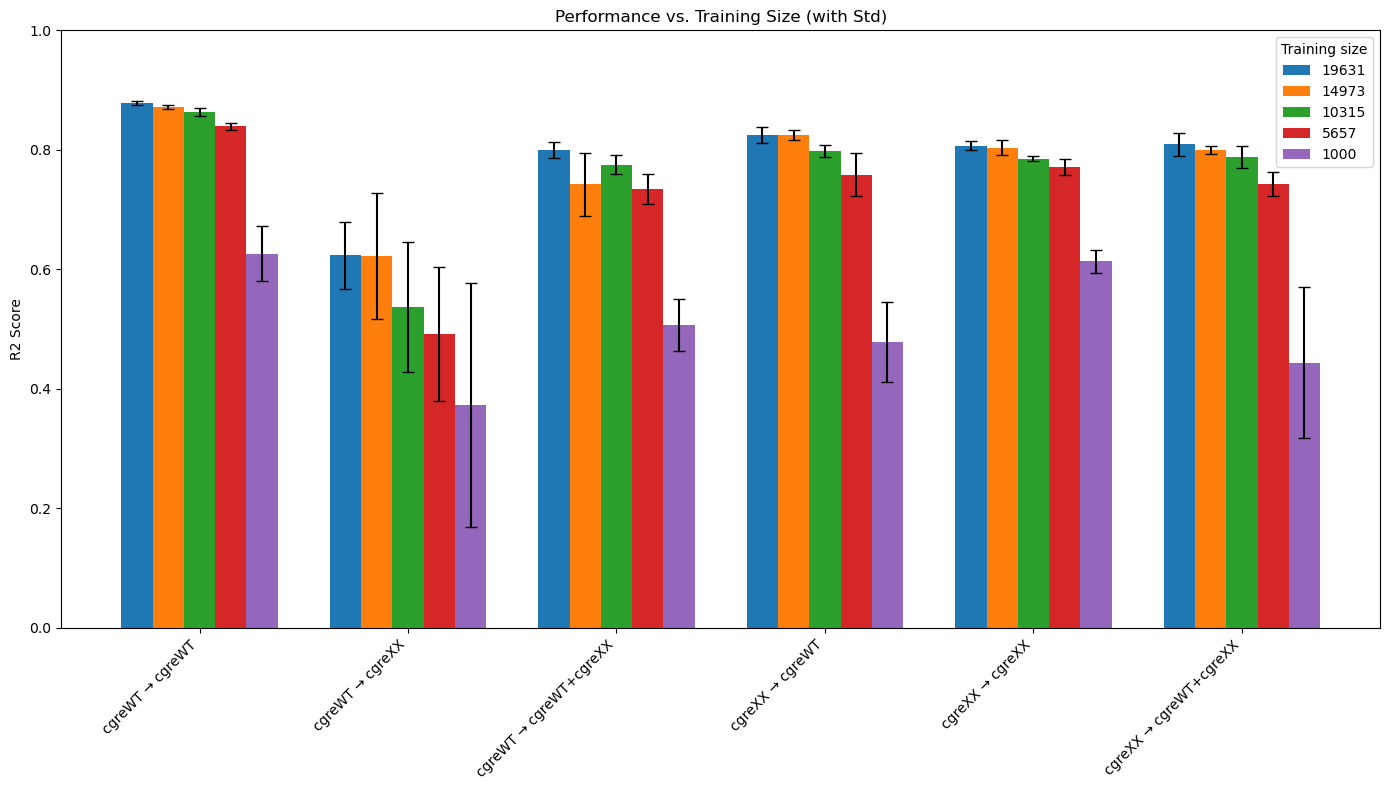

In [4]:
# Load CSV

results = pd.read_csv("../final_results.csv")

# Parse value and std for each numeric column
for col in results.columns[2:]:
    results[f"{col}_value"] = results[col].apply(lambda x: float(x.split('_')[0]))
    results[f"{col}_std"] = results[col].apply(lambda x: float(x.split('_')[1]))


# Categorize strain names
strain_label = lambda x: (
    'cgreWT+cgreXX' if ('cgreGFP' in x and any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111'])) else
    'cgreXX' if any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111']) else
    'cgreWT' if 'cgreGFP' in x else x
)
results['train'] = results['train'].apply(strain_label)
results['test'] = results['test'].apply(strain_label)

# Drop the original combined columns
# results = results.drop(columns=results.columns[2:len(results.columns)//2+1])

# Plotting values and std for each dataset size
dataset_sizes = ["19631", "14973", "10315", "5657", "1000"]
x = np.arange(len(results))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 8))

for i, size in enumerate(dataset_sizes):
    values = results[f"{size}_value"]
    stds = results[f"{size}_std"]
    ax.bar(x + i * width, values, width, yerr=stds, label=size, capsize=4)

# Format labels
ax.set_ylabel('R2 Score')
ax.set_title('Performance vs. Training Size (with Std)')
ax.set_xticks(x + width * (len(dataset_sizes) - 1) / 2)
ax.set_xticklabels([f"{train} \u2192 {test}" for train, test in zip(results['train'], results['test'])], rotation=45, ha='right')
ax.legend(title='Training size')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


/var/folders/5x/72bglw1x1178wdf5_zjmlpjw0000gn/T/ipykernel_50179/2980618876.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10')


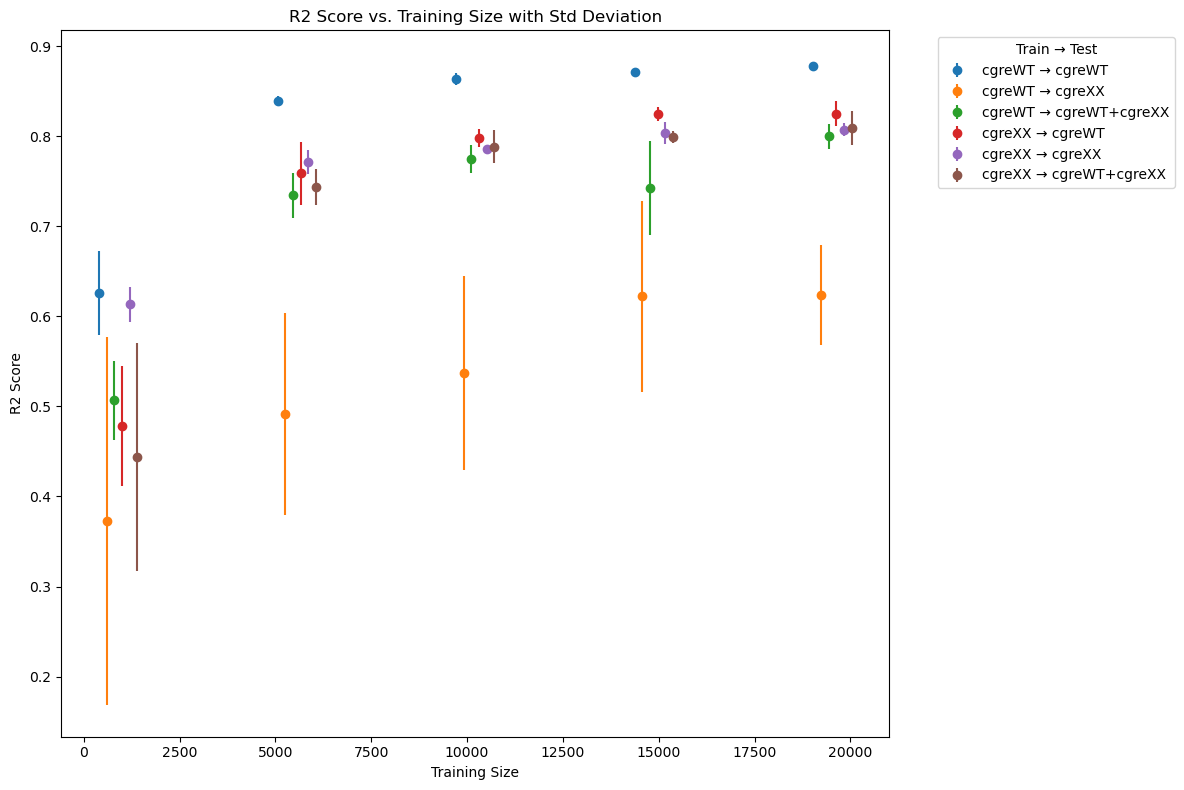

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Load CSV
results = pd.read_csv("../final_results.csv")

# Categorize strain names
strain_label = lambda x: (
    'cgreWT+cgreXX' if ('cgreGFP' in x and any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111'])) else
    'cgreXX' if any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111']) else
    'cgreWT' if 'cgreGFP' in x else x
)
results['train'] = results['train'].apply(strain_label)
results['test'] = results['test'].apply(strain_label)

# Parse value and std for each training size
training_sizes = ["19631", "14973", "10315", "5657", "1000"]
for col in training_sizes:
    results[f"{col}_value"] = results[col].apply(lambda x: float(x.split('_')[0]))
    results[f"{col}_std"] = results[col].apply(lambda x: float(x.split('_')[1]))

# Drop the original value_std columns
results = results.drop(columns=training_sizes)

# Prepare plot
fig, ax = plt.subplots(figsize=(12, 8))
color_map = cm.get_cmap('tab10')

# Create unique label for each train → test pair
results['pair'] = results.apply(lambda row: f"{row['train']} → {row['test']}", axis=1)
unique_pairs = results['pair'].unique()
colors = {pair: color_map(i % 10) for i, pair in enumerate(unique_pairs)}

# Plot each point with error bars, offsetting slightly to avoid overlap
offset_step = 200  # spacing between dots at the same training size

for i, pair in enumerate(unique_pairs):
    subset = results[results['pair'] == pair]
    offset = (i - len(unique_pairs) / 2) * offset_step
    for _, row in subset.iterrows():
        for j, size in enumerate(training_sizes):
            x = int(size) + offset
            y = row[f"{size}_value"]
            yerr = row[f"{size}_std"]
            ax.errorbar(x, y, yerr=yerr, fmt='o', color=colors[pair], label=pair)

# Fix legend: remove duplicates
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Train → Test", bbox_to_anchor=(1.05, 1), loc='upper left')

# Axis labels and title
ax.set_xlabel("Training Size")
ax.set_ylabel("R2 Score")
ax.set_title("R2 Score vs. Training Size with Std Deviation")
plt.tight_layout()
plt.show()

In [6]:
!ls


3344_836_cgre_all_against_all_final_results.csv
3344_836_final_results_everyone_else.csv
3344_cgre_artificial_final_results.csv
ML_cross-genes.png
ML_cross-genes_final_combined.png
WTGFPs_val_cgreGFP_results.csv
WTGFPs_val_cgreGFP_results.png
WTGFPs_val_cgreGFP_results_notcut.png
WTGFPs_val_cgreGFP_results_notcut.pptx
all_combined.xlsx
artificialGFPs_val_cgreGFP_results.png
bombing.csv
cgreGFP_cgreGFP_seeds_3344_train_836_test.csv
final_results_ranged_check.csv
gfps_distance.png
loading_individual.ipynb
test_cgre_on_WTcgreGFP.csv
v_results.csv


In [7]:
# Define color mapping based on train/test combos
def get_color(train, test):
    wt = ['cgreWT', 'cgreGFP']
    xx = ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111']
    amac = ['amacGFP']
    pplu = ['ppluGFP']

    train_set = set(train.split('+'))
    test_set = set(test.split('+'))

    if train == test and len(train.split()) == 1:
        return '#F7DC6F'  # yellow
    elif 'cgreGFP' in train:
        if any(t in test for t in xx):
            return '#AED6F1'
        return '#D5F5E3'  # fallback greenish
    elif any(t in train for t in xx) and 'cgreGFP' in test:
        return '#AED6F1'  # light blue
    else:
        return '#D5F5E3'  # fallback gray

# Assign colors
colors = [get_color(t, s) for t, s in zip(results['train'], results['test'])]


In [8]:
# Load CSV

results = pd.read_csv("v_results.csv")

# Parse value and std for each numeric column
for col in results.columns[2:]:
    print(col)
    results[f"{col}_value"] = results[col].apply(lambda x: float(x.split('_')[0]))
    results[f"{col}_std"] = results[col].apply(lambda x: float(x.split('_')[1]))


# # Categorize strain names
# strain_label = lambda x: (
#     'cgreWT+cgreXX' if ('cgreGFP' in x and any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111'])) else
#     'cgreXX' if any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111']) else
#     'cgreWT' if 'cgreGFP' in x else x
# )
# results['train'] = results['train'].apply(strain_label)
# results['test'] = results['test'].apply(strain_label)

# Drop the original combined columns
# results = results.drop(columns=results.columns[2:len(results.columns)//2+1])

# Plotting values and std for each dataset size
dataset_sizes = ["3344",]
x = np.arange(len(results))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 8))

for i, size in enumerate(dataset_sizes):
    values = results[f"{size}_value"]
    stds = results[f"{size}_std"]
ax.bar(x + i * width, values, width, yerr=stds, label=size, capsize=4, color=colors)

# Format labels
ax.set_ylabel('R2 Score')
ax.set_title('Performance vs. Training Size (with Std)')
ax.set_xticks(x + width * (len(dataset_sizes) - 1) / 2)
ax.set_xticklabels([f"{train} \u2192 {test}" for train, test in zip(results['train'], results['test'])], rotation=45, ha='right')
# ax.legend(title='Training size')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


3344
Unnamed: 3


AttributeError: 'float' object has no attribute 'split'

In [ ]:
df = pd.read_csv("../FINAL_DATASET.csv")

genes =['cgre132', 'cgre1338', 'cgre4111','cgre9708', 'cgreGFP', 'minis']
for gene in genes:
    num = len(df[df["gene"] == gene])
    test_size = round(num * 0.2)
    train_size = num - test_size

    print(f"{gene}: {train_size} train, {test_size} test")

cgre132: 3414 train, 853 test
cgre1338: 7147 train, 1787 test
cgre4111: 6572 train, 1643 test
cgre9708: 3344 train, 836 test
cgreGFP: 19631 train, 4908 test
minis: 555 train, 139 test


In [9]:
results

,train,test,3344,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,3344_value,3344_std
0,cgreGFP,cgreGFP,0.8160_0.0139,NaN,NaN,NaN,NaN,NaN,NaN,0.816000,0.013900
1,ppluGFP,cgreGFP,0.0050_0.0366,NaN,NaN,NaN,NaN,NaN,NaN,0.005000,0.036600
2,amacGFP,cgreGFP,-0.0070_0.1408,NaN,NaN,NaN,NaN,NaN,NaN,-0.007000,0.140800
3,cgreGFP amacGFP,cgreGFP,0.7676_0.0323,NaN,NaN,NaN,NaN,NaN,NaN,0.767600,0.032300
4,amacGFP ppluGFP,cgreGFP,-0.0227_0.1437,NaN,NaN,NaN,NaN,NaN,NaN,-0.022700,0.143700
5,cgreGFP ppluGFP,cgreGFP,0.7458_0.0297,NaN,NaN,NaN,NaN,NaN,NaN,0.745800,0.029700
6,cgreGFP amacGFP ppluGFP,cgreGFP,0.7517_0.0183,NaN,NaN,NaN,NaN,NaN,NaN,0.751700,0.018300
7,avGFP,avGFP,0.8133_0.0088,NaN,NaN,NaN,NaN,NaN,NaN,0.813300,0.008800
8,cgreGFP,cgreGFP,0.7989_0.0296,NaN,NaN,NaN,NaN,NaN,NaN,0.798900,0.029600
9,ppluGFP,ppluGFP,0.794_0.0314,NaN,NaN,NaN,NaN,NaN,NaN,0.794000,0.031400


In [10]:
import cmocean

# Start with your fixed r2 dictionary
# r2 = {
#     'amacGFP': 0.78, 'amacGFP\navGFP': 0.69, 'amacGFP\ncgreGFP': 0.71, 'amacGFP\nppluGFP': 0.725,
#     'amacGFP\navGFP\ncgreGFP': 0.66, 'amacGFP\navGFP\nppluGFP': 0.67, 'amacGFP\ncgreGFP\nppluGFP': 0.69,
#     'amacGFP\navGFP\ncgreGFP\nppluGFP': 0.65, 'avGFP': 0.2, 'cgreGFP': 0.06, 'ppluGFP': 0.32,
#     'avGFP\ncgreGFP': 0.31, 'avGFP\nppluGFP': 0.43, 'cgreGFP\nppluGFP': 0.345,
#     'avGFP\ncgreGFP\nppluGFP': 0.46
# }

results = pd.read_csv("v_results.csv")
for col in results.columns[2:]:
    print(col)
    results[f"{col}_value"] = results[col].apply(lambda x: float(x.split('_')[0]))
    results[f"{col}_std"] = results[col].apply(lambda x: float(x.split('_')[1]))

results = results.iloc[0:7]


r2 = {}

# Now add from the DataFrame
r2_err = {k: 0 for k in r2}  # std=0 for original entries

for _, row in results.iterrows():
    label = row['train'] # ensure consistent label style
    r2[label] = row['3344_value']
    r2_err[label] = row['3344_std']

# Plot
plt.figure(figsize=[7,6], dpi=300)
ax = plt.subplot(111)
ax.spines[['top', 'left', 'right', 'bottom']].set_visible(False)
plt.grid(alpha=0.5, color='k', linestyle=':')

x = np.arange(len(r2))
heights = list(r2.values())
errors = list(r2_err.values())

# Plot bars with error bars
plt.bar(x, height=heights, yerr=errors, 
        color=cmocean.cm.algae(125), edgecolor='k', zorder=100,
        capsize=5, error_kw=dict(ecolor='gray', lw=2))



# Helper: check if gene (e.g. 'amac') matches label (e.g. 'amacGFP' or 'cgre1338\nGFP')
def gene_in_label(gene, label):
    return gene in label.split()

# GFP composition markers
for i, gene in enumerate(['cgre', 'amac', 'pplu']):
    print(r2.keys())
    plt.scatter(
        x, [(-i-3)/8]*len(x), edgecolor='k', s=500,
        c=[cmocean.cm.algae(125) if gene_in_label(gene + "GFP", k) else 'w' for k in r2.keys()],
        zorder=100
    )
    plt.text(x=-1, y=(-i-3)/8, s=f'{gene}GFP', weight='bold',
             va='center', ha='right', fontsize=14)

plt.text(x=-2.6, y=-0.5, s='Training set', rotation=90, ha='center', va='center', fontsize=14)
plt.yticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1], [-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
plt.text(x=-2.25, y=0.4, s=r'$\rho$' + '\n\nValidation\non cgreGFP', fontsize=14, ha='center', va='center')
plt.xticks([], [])


plt.savefig('WTGFPs_val_cgreGFP_results.png', dpi=200)


results.to_csv("WTGFPs_val_cgreGFP_results.csv", index=False)

3344
Unnamed: 3


AttributeError: 'float' object has no attribute 'split'

In [11]:
test_on_cgreGFP = pd.read_csv("test_cgre_on_WTcgreGFP.csv")
# Identify seed columns dynamically
seed_cols = [col for col in test_on_cgreGFP.columns if col.startswith("seed_")]

# Group by 'train' and aggregate seed values
def aggregate_seeds(group):
    seeds = group[seed_cols].values.flatten()
    seeds = seeds[~np.isnan(seeds)]  # remove NaN
    return pd.Series({
        'final_combined': np.mean(seeds),
        'std_combined': np.std(seeds, ddof=0),  # population std
        'num_seeds': len(seeds)
    })

# Group and aggregate
test_on_cgreGFP = test_on_cgreGFP.groupby('train').apply(aggregate_seeds).reset_index()
test_on_cgreGFP

/var/folders/5x/72bglw1x1178wdf5_zjmlpjw0000gn/T/ipykernel_50179/1082801535.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_on_cgreGFP = test_on_cgreGFP.groupby('train').apply(aggregate_seeds).reset_index()


,train,final_combined,std_combined,num_seeds
0,cgre132,0.591557,0.124782,10.0
1,cgre1338,0.553756,0.083343,10.0
2,cgre1338 cgre132,0.729019,0.020640,10.0
3,cgre1338 cgre132 cgre9708 cgre4111,0.663913,0.039956,5.0
4,cgre1338 cgre4111,0.618366,0.096443,10.0
5,cgre4111,0.436572,0.142872,10.0
6,cgre9708,0.570051,0.062849,10.0
7,cgre9708 cgre132,0.573220,0.094339,10.0
8,cgre9708 cgre4111,0.636101,0.075323,10.0
9,cgreGFP,0.807431,0.024635,10.0


In [12]:
def count_genes(label):
    if label == "cgreGFP":
        return -1  # Force cgreGFP to the top
    return len(label.split())

# Sort by gene count (special case for cgreGFP), then alphabetically within groups
test_on_cgreGFP['gene_count'] = test_on_cgreGFP['train'].apply(count_genes)
test_on_cgreGFP = test_on_cgreGFP.sort_values(by=['gene_count', 'train'], ascending=[True, True]).reset_index(drop=True)
test_on_cgreGFP = test_on_cgreGFP.drop(columns=['gene_count'])
test_on_cgreGFP

,train,final_combined,std_combined,num_seeds
0,cgreGFP,0.807431,0.024635,10.0
1,cgre132,0.591557,0.124782,10.0
2,cgre1338,0.553756,0.083343,10.0
3,cgre4111,0.436572,0.142872,10.0
4,cgre9708,0.570051,0.062849,10.0
5,cgre1338 cgre132,0.729019,0.020640,10.0
6,cgre1338 cgre4111,0.618366,0.096443,10.0
7,cgre9708 cgre132,0.573220,0.094339,10.0
8,cgre9708 cgre4111,0.636101,0.075323,10.0
9,cgre1338 cgre132 cgre9708 cgre4111,0.663913,0.039956,5.0


[(0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', 'w', 'w', 'w', 'w', 'w', 'w', 'w', 'w']
['w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', 'w', 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0)]
['w', 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0)]
['w', 'w', 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), 'w', (0.08620976681204781, 0.589869671329717, 0.31496950472809665, 1.0), (0.08620976681204781, 0.589869671329717, 0.31

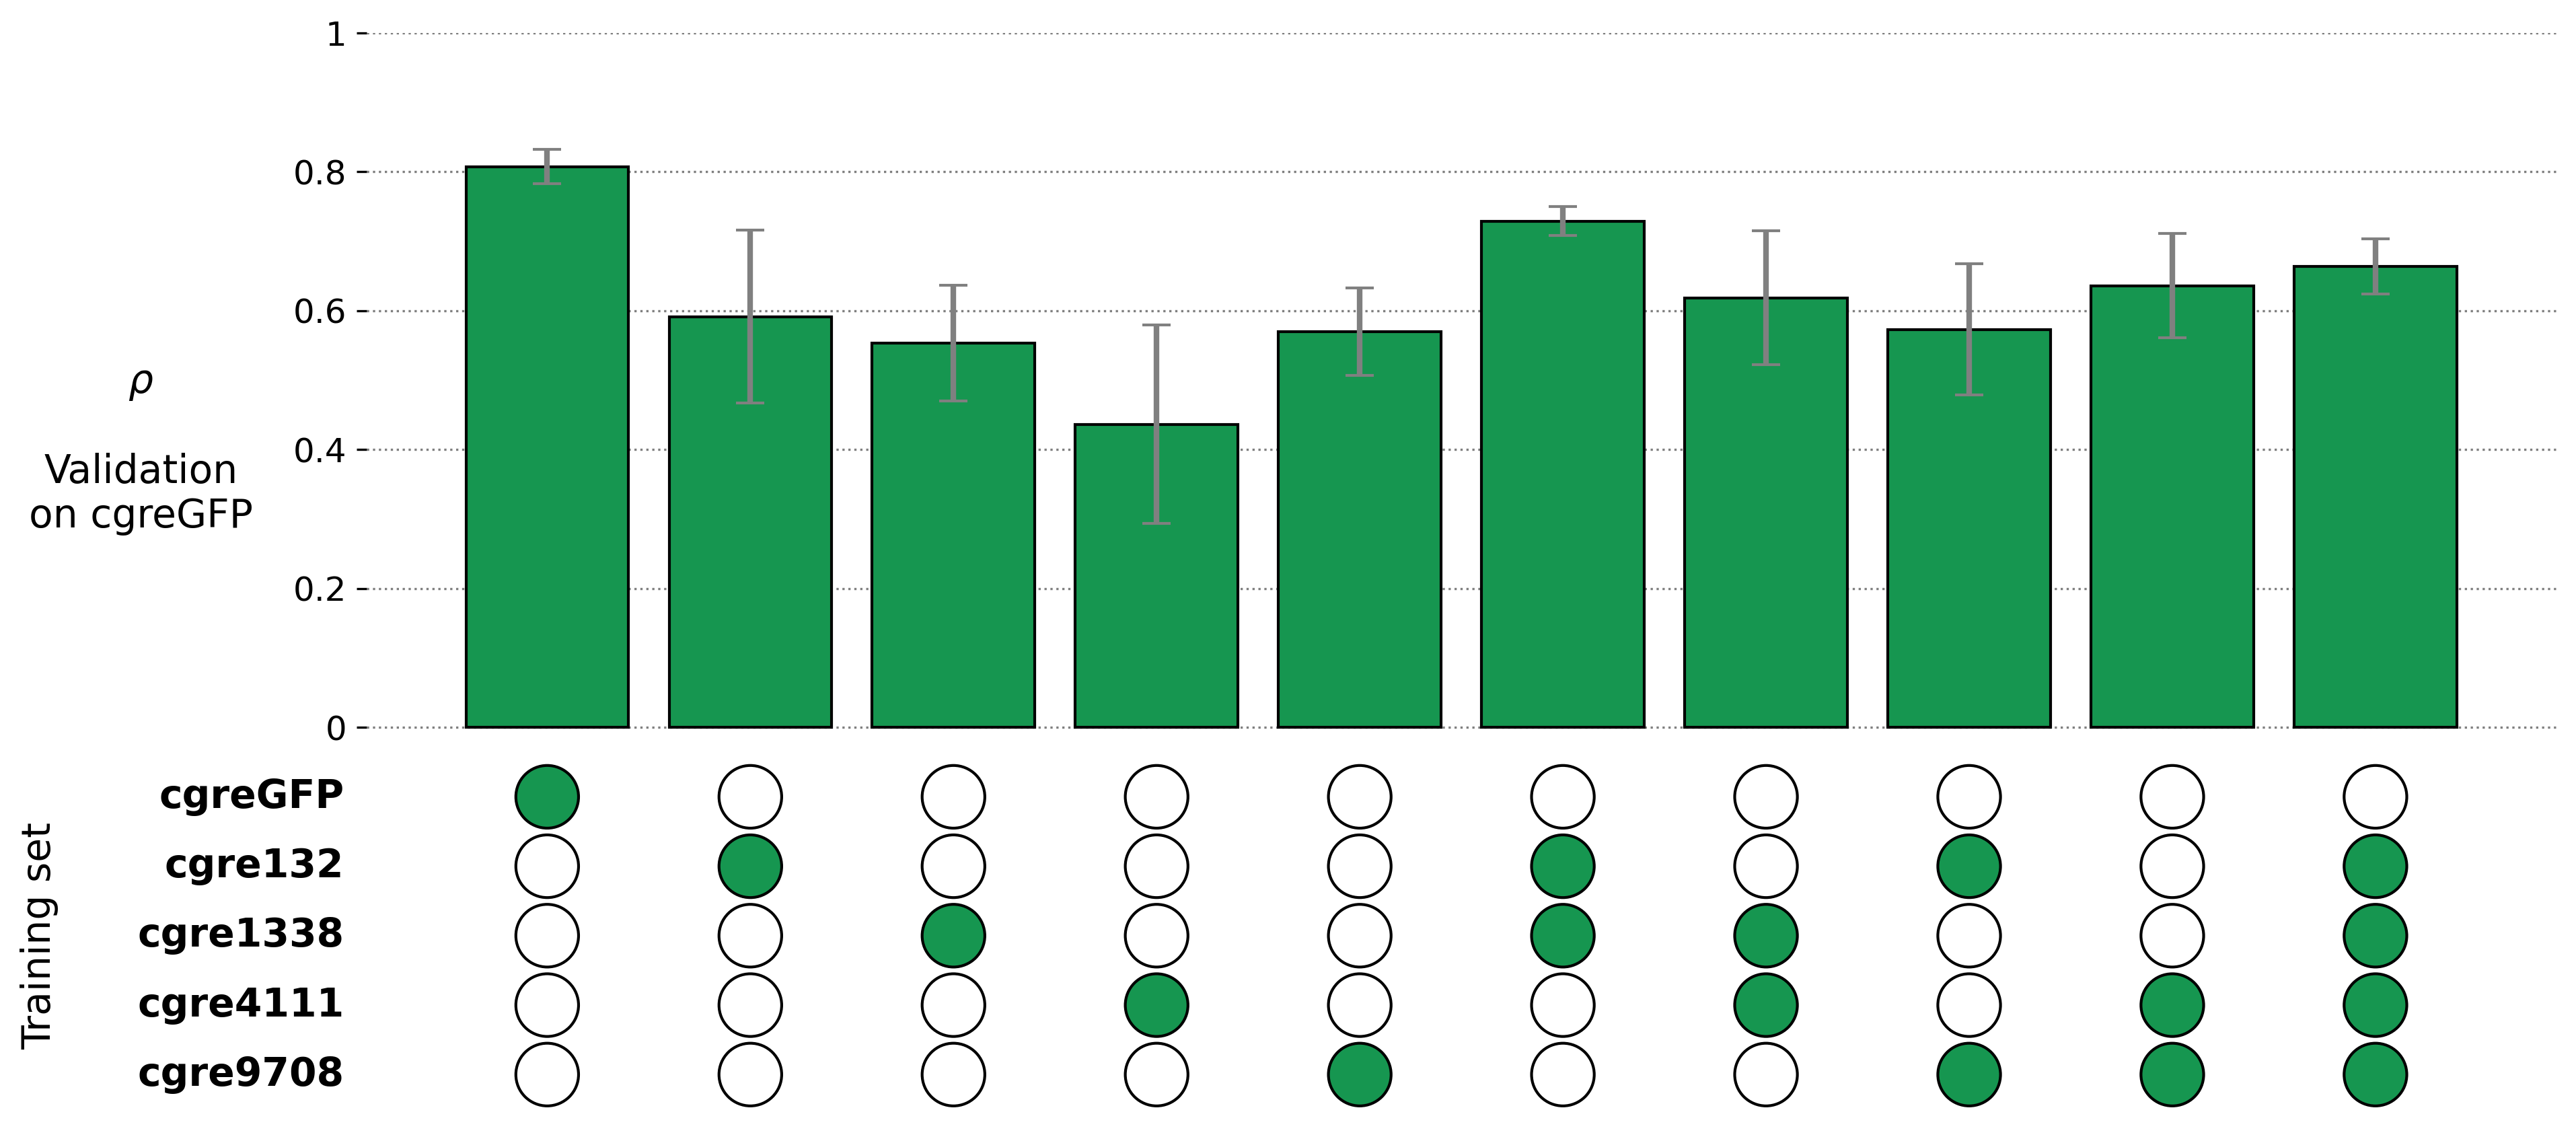

In [13]:
# For plotting:
r2 = dict(zip(test_on_cgreGFP['train'], test_on_cgreGFP['final_combined']))
r2_err = dict(zip(test_on_cgreGFP['train'], test_on_cgreGFP['std_combined']))

plt.figure(figsize=[14,7], dpi=300)
ax = plt.subplot(111)
ax.spines[['top', 'left', 'right', 'bottom']].set_visible(False)
plt.grid(alpha=0.5, color='k', linestyle=':')

x = np.arange(len(r2))
heights = list(r2.values())
errors = list(r2_err.values())

plt.bar(x, height=heights, yerr=errors, 
        color=cmocean.cm.algae(125), edgecolor='k', zorder=100,
        capsize=5, error_kw=dict(ecolor='gray', lw=2))

# Gene marker dots below bars
def gene_in_label(gene, label):
    return gene in label.split()

# GFP composition markers
for i, gene in enumerate(['cgreGFP','cgre132', 'cgre1338', 'cgre4111', 'cgre9708']):
    print([cmocean.cm.algae(125) if gene_in_label(gene , k) else 'w' for k in r2.keys()])
    plt.scatter(
        x, [(-i-1)/10]*len(x), edgecolor='k', s=500,
        c=[cmocean.cm.algae(125) if gene_in_label(gene , k) else 'w' for k in r2.keys()],
        zorder=100
    )
    plt.text(x=-1, y=(-i-1)/10, s=f'{gene}', weight='bold',
             va='center', ha='right', fontsize=14)

plt.text(x=-2.5, y=-0.3, s='Training set', rotation=90, ha='center', va='center', fontsize=14)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], [0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
plt.text(x=-2, y=0.4, s=r'$\rho$' + '\n\nValidation\non cgreGFP', fontsize=14, ha='center', va='center')
plt.xticks([], [])

plt.savefig('artificialGFPs_val_cgreGFP_results.png', dpi=200)

In [14]:
bombing = pd.read_csv("bombing.csv")
bombing = bombing.groupby(['train', 'test']).apply(aggregate_seeds).reset_index()
bombing

/var/folders/5x/72bglw1x1178wdf5_zjmlpjw0000gn/T/ipykernel_50179/1815720084.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bombing = bombing.groupby(['train', 'test']).apply(aggregate_seeds).reset_index()


,train,test,final_combined,std_combined,num_seeds
0,cgre1338 cgre132 cgre9708 cgre4111,cgre1338 cgre132 cgre9708 cgre4111,0.725530,0.017865,5.0
1,cgre1338 cgre132 cgre9708 cgre4111,cgreGFP,0.663913,0.039956,5.0
2,cgreGFP,cgre1338 cgre132 cgre9708 cgre4111,0.517434,0.075897,5.0
3,cgreGFP,cgreGFP,0.807431,0.024635,10.0


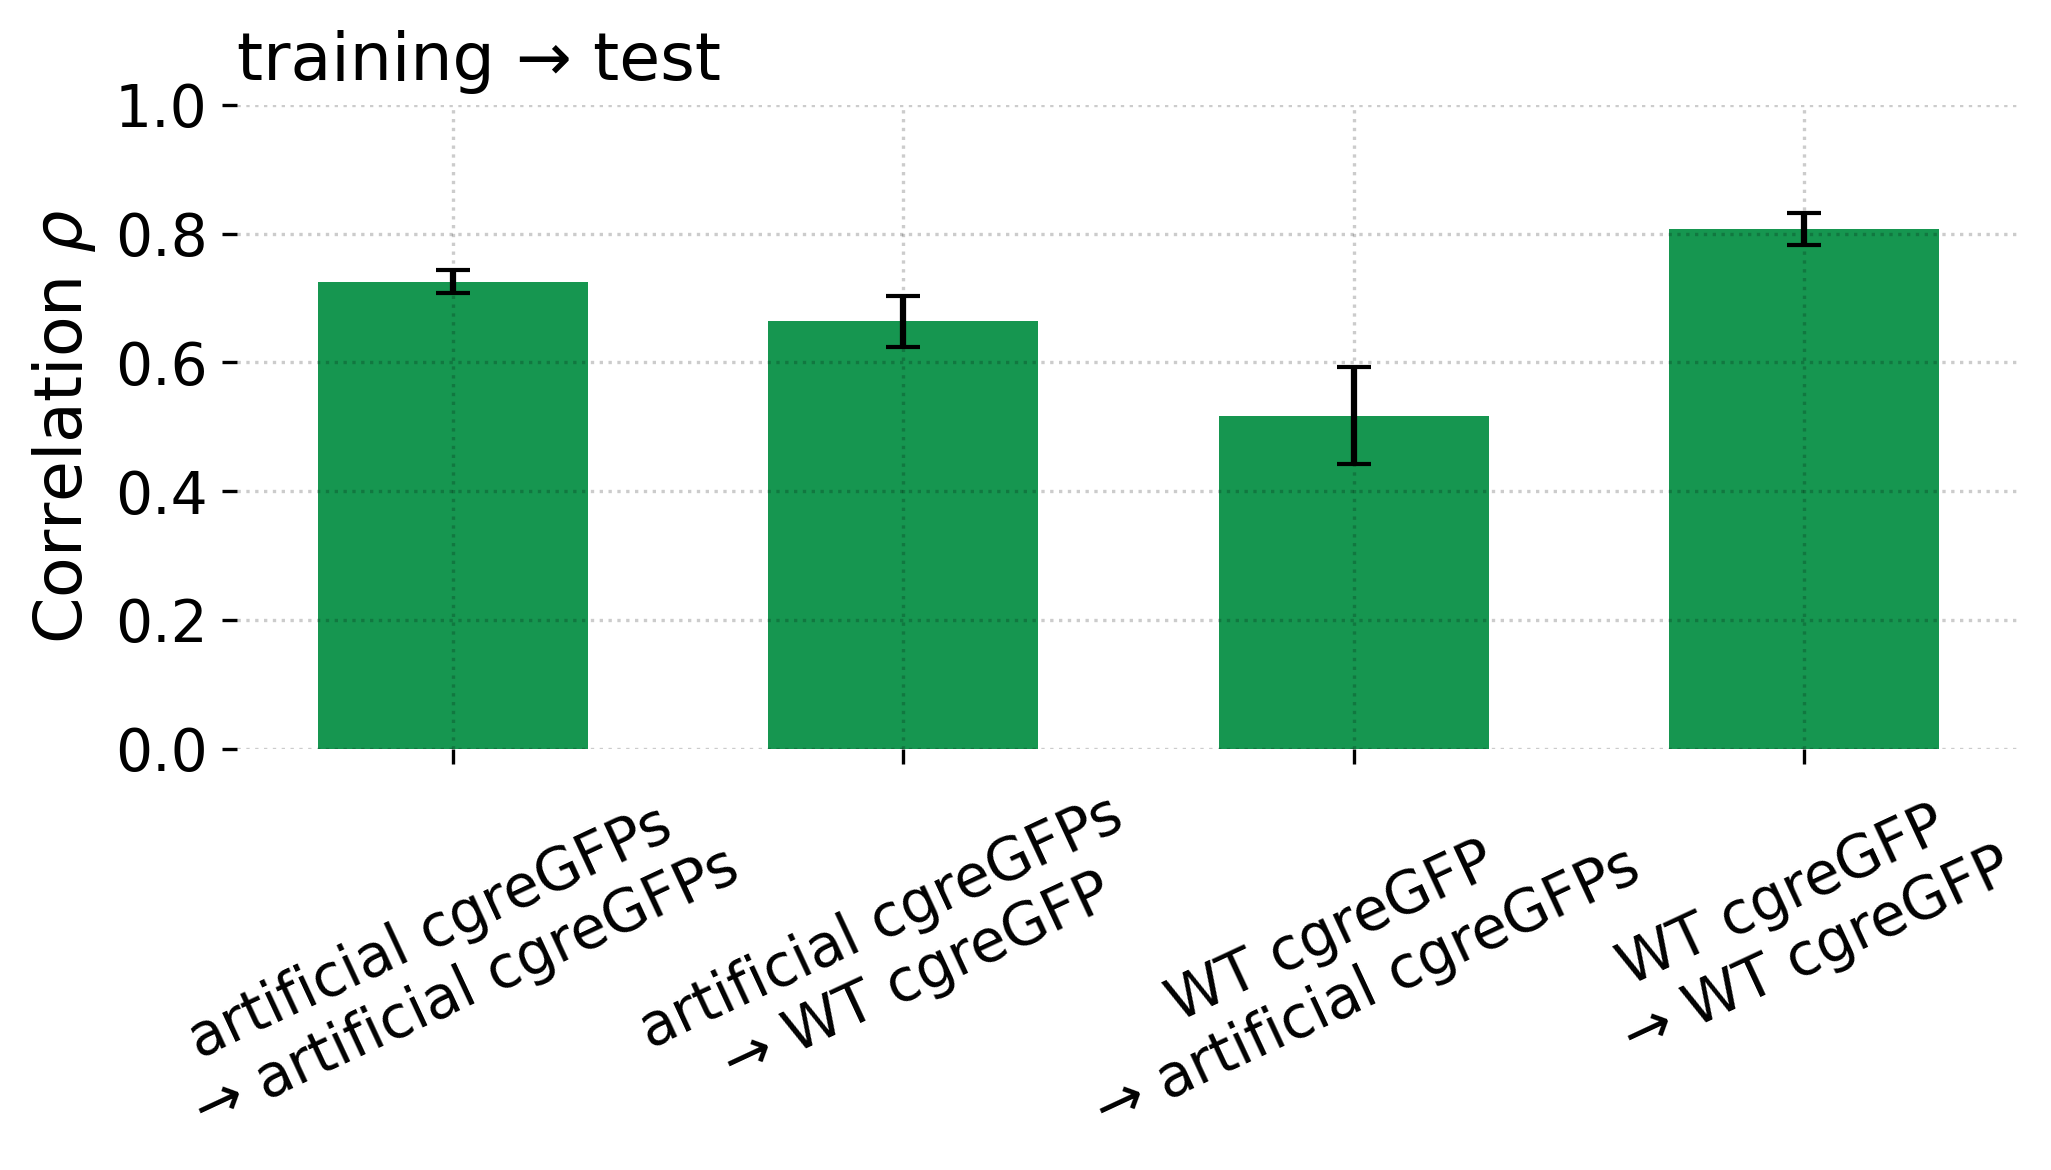

In [27]:
# Dataset (you have one set here, but scalable)
width = 0.15
x = np.arange(len(bombing))

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
ax.bar(x,
       bombing.final_combined,
       width=0.6,
       yerr=bombing.std_combined,
       capsize=4,
       color=cmocean.cm.algae(125))

ax.set_ylabel(r'Correlation $\rho$', fontsize=16)
ax.spines[['top', 'left', 'right', 'bottom']].set_visible(False)
plt.grid(alpha=0.2, color='k', linestyle=':')

name_map = {
    "cgreGFP": "WT cgreGFP",
    "cgre9708": "artificial cgreGFP",
    "cgre132": "artificial cgreGFP",
    "cgre1338": "artificial cgreGFP",
    "cgre4111": "artificial cgreGFP"
}

def simplify_label(label):
    parts = label.split()
    if all(part in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111'] for part in parts):
        return "artificial cgreGFPs"
    if 'cgreGFP' in parts and len(parts) == 1:
        return "WT cgreGFP"
    return label  # fallback in case of unexpected label

def short_label(train, test):
    train_label = simplify_label(train)
    test_label = simplify_label(test)
    return f"{train_label} \n→ {test_label}"


ax.set_xticks(x)
ax.set_xticklabels([short_label(t, te) for t, te in zip(bombing['train'], bombing['test'])],
                   rotation=25, ha='center', fontsize=14)

ax.tick_params(axis='y', labelsize=14)
plt.ylim(0, 1)

plt.title('training → test', fontsize=16, loc='left')
plt.tight_layout()
plt.show()

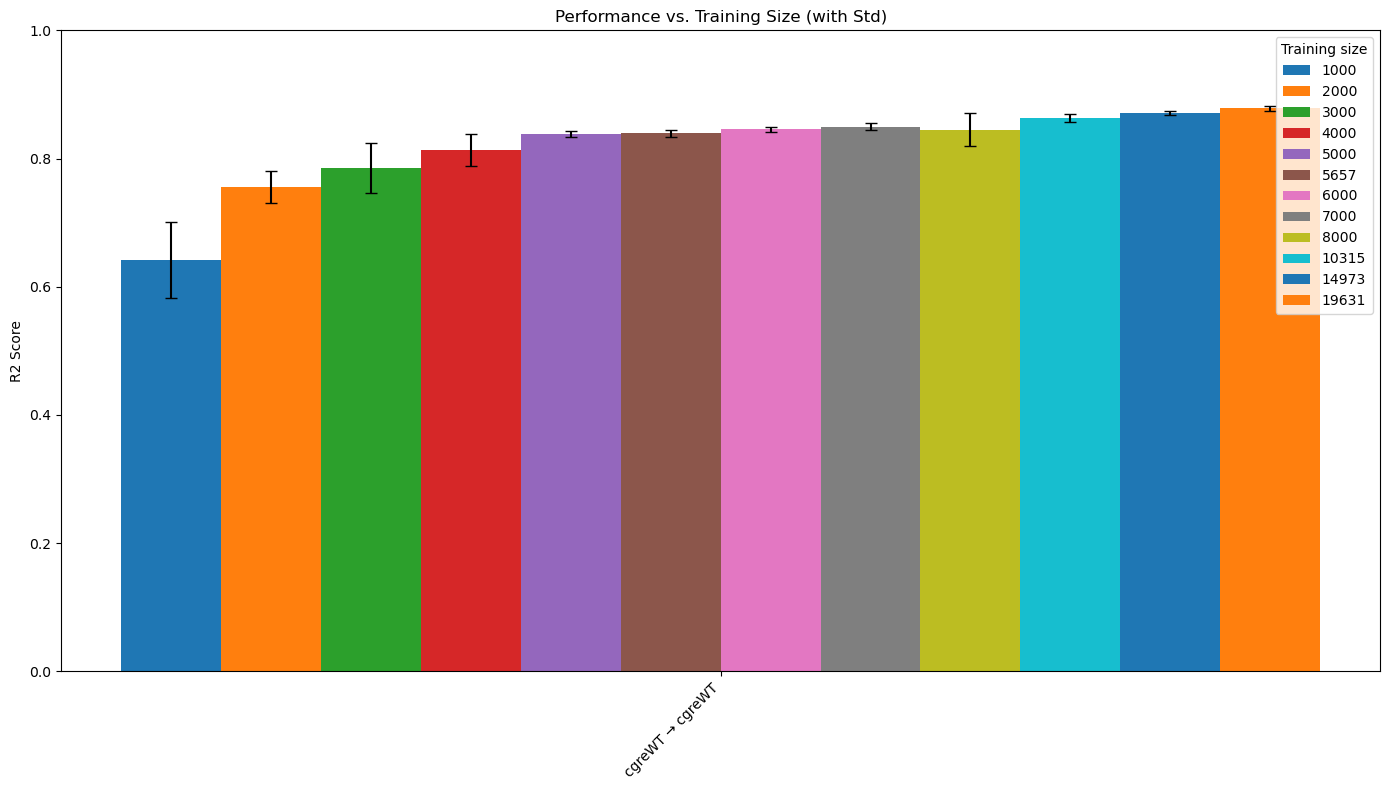

In [16]:
# Load CSV

results = pd.read_csv("final_results_ranged_check.csv")

# Parse value and std for each numeric column
for col in results.columns[2:]:
    results[f"{col}_value"] = results[col].apply(lambda x: float(x.split('_')[0]))
    results[f"{col}_std"] = results[col].apply(lambda x: float(x.split('_')[1]))


# Categorize strain names
strain_label = lambda x: (
    'cgreWT+cgreXX' if ('cgreGFP' in x and any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111'])) else
    'cgreXX' if any(g in x for g in ['cgre1338', 'cgre132', 'cgre9708', 'cgre4111']) else
    'cgreWT' if 'cgreGFP' in x else x
)
results['train'] = results['train'].apply(strain_label)
results['test'] = results['test'].apply(strain_label)

# Drop the original combined columns
# results = results.drop(columns=results.columns[2:len(results.columns)//2+1])

# Plotting values and std for each dataset size
dataset_sizes = ["1000", "2000", "3000", "4000", "5000", "5657", "6000", "7000", "8000", "10315", "14973", "19631", ]
x = np.arange(len(results))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 8))

for i, size in enumerate(dataset_sizes):
    values = results[f"{size}_value"]
    stds = results[f"{size}_std"]
    ax.bar(x + i * width, values, width, yerr=stds, label=size, capsize=4)

# Format labels
ax.set_ylabel('R2 Score')
ax.set_title('Performance vs. Training Size (with Std)')
ax.set_xticks(x + width * (len(dataset_sizes) - 1) / 2)
ax.set_xticklabels([f"{train} \u2192 {test}" for train, test in zip(results['train'], results['test'])], rotation=45, ha='right')
ax.legend(title='Training size')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [17]:
results

,train,test,8000,7000,6000,5000,4000,3000,2000,1000,...,1000_value,1000_std,19631_value,19631_std,14973_value,14973_std,10315_value,10315_std,5657_value,5657_std
0,cgreWT,cgreWT,0.8449_0.0257,0.8495_0.0057,0.8459_0.0040,0.8383_0.0051,0.8132_0.0249,0.7847_0.0392,0.7554_0.0253,0.6411_0.0592,...,0.6411,0.0592,0.8783,0.0036,0.8713,0.0031,0.8633,0.0066,0.8392,0.0059


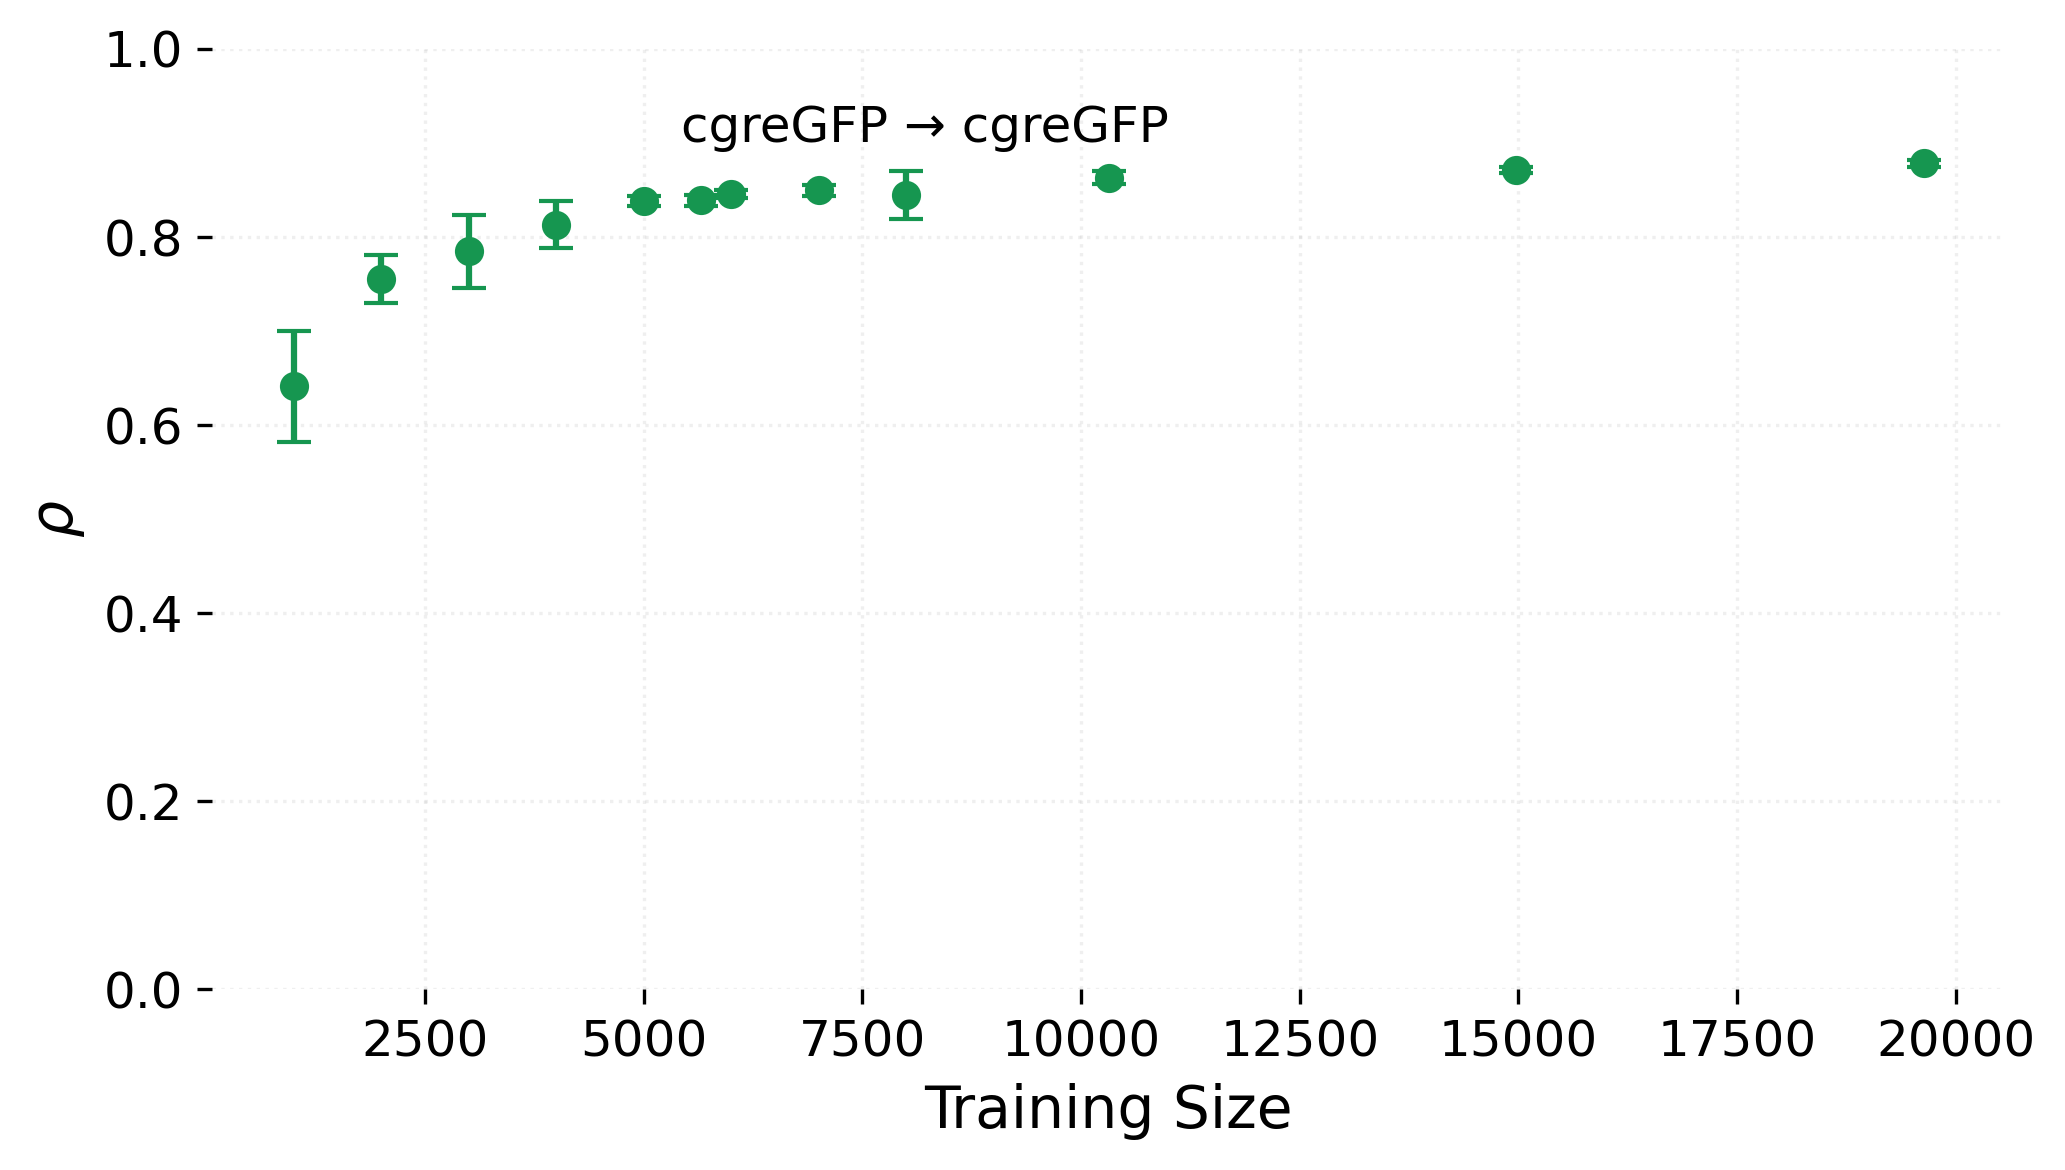

In [18]:
# Load data
results = pd.read_csv("final_results_ranged_check.csv")

training_sizes = ["1000", "2000", "3000", "4000", "5000", "5657", "6000", "7000", "8000", "10315", "14973", "19631"]
for col in training_sizes:
    results[f"{col}_value"] = results[col].apply(lambda x: float(x.split('_')[0]))
    results[f"{col}_std"] = results[col].apply(lambda x: float(x.split('_')[1]))
results = results.drop(columns=training_sizes)

# Build pair labels
results['pair'] = results.apply(lambda row: f"{row['train']} → {row['test']}", axis=1)
unique_pairs = results['pair'].unique()

# Colors from algae colormap
color_map = cmocean.cm.algae
colors = {pair: color_map(i / max(len(unique_pairs)-1,1)) for i, pair in enumerate(unique_pairs)}

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
ax.spines[['top', 'right']].set_visible(False)
plt.grid(alpha=0.2, linestyle=':')

for pair in unique_pairs:
    subset = results[results['pair'] == pair].iloc[0]
    y_values = [subset[f"{size}_value"] for size in training_sizes]
    y_errors = [subset[f"{size}_std"] for size in training_sizes]
    x_values = [int(size) for size in training_sizes]
    
    ax.errorbar(x_values, y_values, yerr=y_errors, fmt='o', markersize=6,
                color=cmocean.cm.algae(125), capsize=4)


ax.spines[['top', 'left', 'right', 'bottom']].set_visible(False)

# Optional: labels near first point
for pair in unique_pairs:
    subset = results[results['pair'] == pair].iloc[0]
    x = int(training_sizes[0])
    y = subset[f"{training_sizes[0]}_value"]
    ax.text(x + 10000, y + 0.3, pair, fontsize=12, ha='right', va='top')

ax.set_ylabel(r'$\rho$', fontsize=14)
ax.set_xlabel("Training Size", fontsize=14)
ax.set_ylim(0, 1)
# ax.tick_params(labelsize=12, rotation=25)
ax.tick_params(labelsize=12)

# ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()


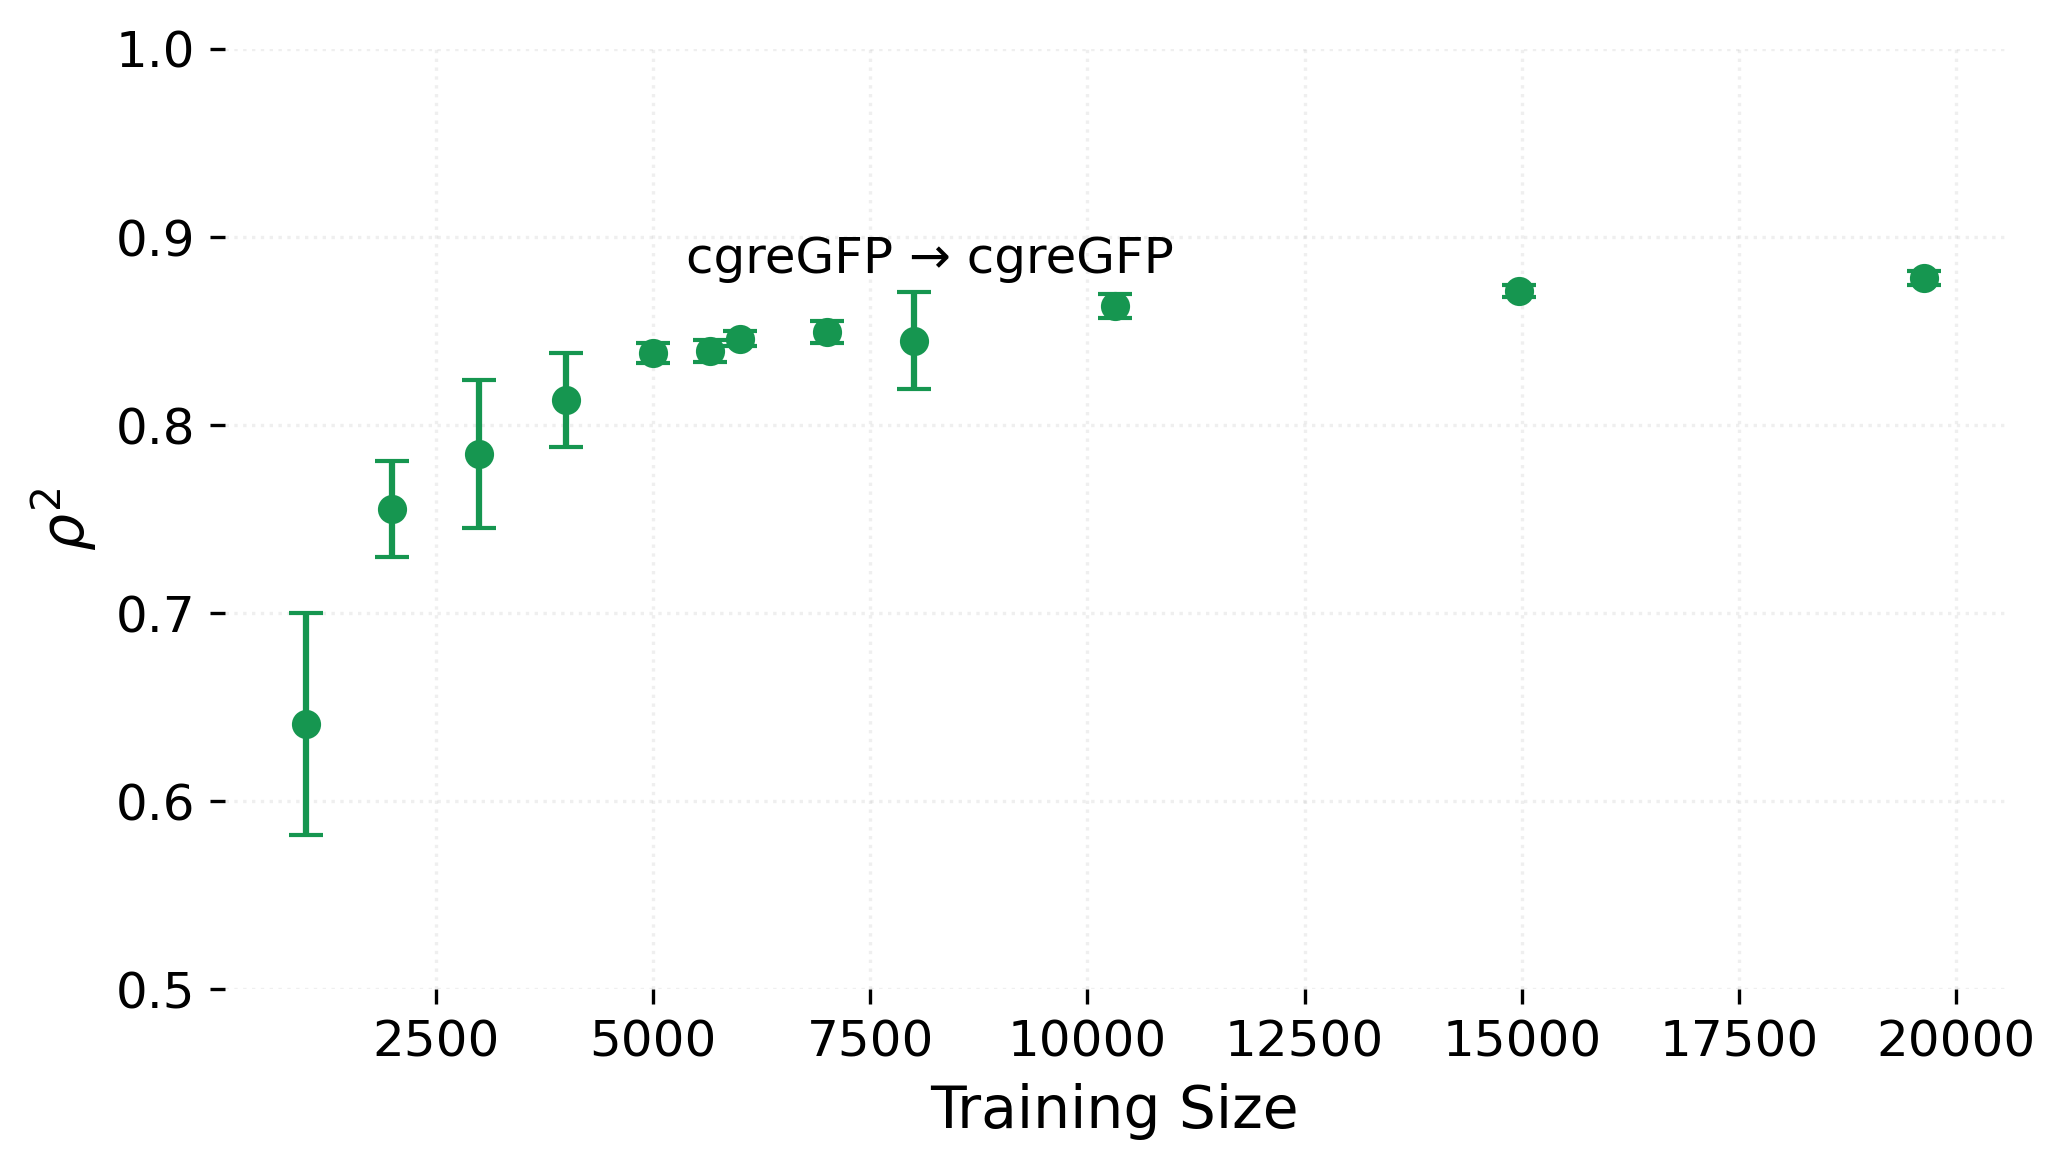

In [19]:
# Load data
results = pd.read_csv("final_results_ranged_check.csv")

training_sizes = ["1000", "2000", "3000", "4000", "5000", "5657", "6000", "7000", "8000", "10315", "14973", "19631"]
for col in training_sizes:
    results[f"{col}_value"] = results[col].apply(lambda x: float(x.split('_')[0]))
    results[f"{col}_std"] = results[col].apply(lambda x: float(x.split('_')[1]))
results = results.drop(columns=training_sizes)

# Build pair labels
results['pair'] = results.apply(lambda row: f"{row['train']} → {row['test']}", axis=1)
unique_pairs = results['pair'].unique()

# Colors from algae colormap
color_map = cmocean.cm.algae
colors = {pair: color_map(i / max(len(unique_pairs)-1,1)) for i, pair in enumerate(unique_pairs)}

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
ax.spines[['top', 'right']].set_visible(False)
plt.grid(alpha=0.2, linestyle=':')

for pair in unique_pairs:
    subset = results[results['pair'] == pair].iloc[0]
    y_values = [subset[f"{size}_value"] for size in training_sizes]
    y_errors = [subset[f"{size}_std"] for size in training_sizes]
    x_values = [int(size) for size in training_sizes]
    
    ax.errorbar(x_values, y_values, yerr=y_errors, fmt='o', markersize=6,
                color=cmocean.cm.algae(125), capsize=4)


ax.spines[['top', 'left', 'right', 'bottom']].set_visible(False)

# Optional: labels near first point
for pair in unique_pairs:
    subset = results[results['pair'] == pair].iloc[0]
    x = int(training_sizes[0])
    y = subset[f"{training_sizes[0]}_value"]
    ax.text(x + 10000, y + 0.26, pair, fontsize=12, ha='right', va='top')

ax.set_ylabel(r'$\rho^2$', fontsize=14)
ax.set_xlabel("Training Size", fontsize=14)
ax.set_ylim(0.5, 1)
# ax.tick_params(labelsize=12, rotation=25)
ax.tick_params(labelsize=12)

# ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()
